# 🏆 VISTA — AI Semantic Segmentation Pipeline (Production)
## Tahap 2: Physical Environment Assessment (Computer Vision)

**Tim FiveHonk! — WebGIS Competition MAPID 2026**

---

Notebook ini menganalisis **17.000+ citra Google Street View** menggunakan model **SegFormer** untuk mengekstraksi indikator visual:

| Indikator | Deskripsi | Kelas Cityscapes |
|---|---|---|
| **Sky View Factor (SVF)** | Proporsi langit terlihat | Class 10: Sky |
| **Green View Index (GVI)** | Proporsi vegetasi/pohon | Class 8: Vegetation |
| **Road Width Index** | Proporsi jalan | Class 0: Road |
| **Street Canyon Enclosure** | Proporsi bangunan | Class 2: Building |
| **Sidewalk Ratio** | Proporsi trotoar | Class 1: Sidewalk |

**Referensi Proposal:** Tabel 4, View-based Streetscape Perception (Physical)

### ⚡ Optimasi untuk Pemrosesan Massal:
1. **ZIP-based I/O** — Gambar di-copy ke mesin lokal Colab agar tidak bottleneck di Google Drive
2. **Batch Processing + Auto-save** — Hasil disimpan setiap 500 gambar agar tidak hilang jika sesi terputus
3. **GPU Memory Management** — Cache GPU dibersihkan berkala agar tidak crash
4. **TAS-Nit Aggregation** — Skor diagregasi dari per-gambar menjadi per-TAS-Nit (5.876 segmen)

## 1. Setup Environment & Mount Google Drive

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# ⚠️ SESUAIKAN PATH INI DENGAN LOKASI FOLDER ANDA DI DRIVE
# ============================================================
BASE_PATH = '/content/drive/MyDrive/ai_pipeline'

import os
DRIVE_IMAGE_DIR = os.path.join(BASE_PATH, 'data', 'images')
OUTPUT_DIR = os.path.join(BASE_PATH, 'data')

if os.path.exists(DRIVE_IMAGE_DIR):
    images = [f for f in os.listdir(DRIVE_IMAGE_DIR) if f.lower().endswith(('.jpg', '.jpeg'))]
    real_images = [f for f in images if os.path.getsize(os.path.join(DRIVE_IMAGE_DIR, f)) > 5000]
    print(f'📁 Folder ditemukan: {DRIVE_IMAGE_DIR}')
    print(f'🖼️  Total file gambar (JPG): {len(images)}')
    print(f'✅ Gambar valid (>5KB): {len(real_images)}')
    if len(real_images) == 0:
        print('\n⚠️  PERINGATAN: Semua gambar berukuran < 5KB (kemungkinan dummy/placeholder).')
else:
    print(f'❌ Folder tidak ditemukan: {DRIVE_IMAGE_DIR}')
    print('   Pastikan Anda sudah meng-upload folder ai_pipeline ke Google Drive.')

Mounted at /content/drive
📁 Folder ditemukan: /content/drive/MyDrive/ai_pipeline/data/images
🖼️  Total file gambar (JPG): 5
✅ Gambar valid (>5KB): 5


## 2. Copy Gambar ke Mesin Lokal Colab (KRITIS untuk Performa!)

Membaca 17.000 file kecil langsung dari Google Drive akan sangat lambat karena setiap akses file harus melalui jaringan. Dengan meng-copy ke `/content/local_images/`, semua operasi baca menjadi secepat SSD lokal.

In [2]:
import shutil
import time

LOCAL_IMAGE_DIR = '/content/local_images'

# Cek apakah ada ZIP file (cara tercepat)
zip_path = os.path.join(BASE_PATH, 'data', 'images.zip')
if os.path.exists(zip_path):
    print(f'📦 ZIP ditemukan: {zip_path}')
    print('Mengekstrak ZIP ke mesin lokal...')
    !unzip -q -o "{zip_path}" -d /content/local_images_temp
    # Cari folder yang berisi gambar (bisa langsung atau di subfolder)
    for root, dirs, files in os.walk('/content/local_images_temp'):
        jpg_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg'))]
        if len(jpg_files) > 100:
            LOCAL_IMAGE_DIR = root
            break
    print(f'✅ ZIP diekstrak ke: {LOCAL_IMAGE_DIR}')
else:
    # Fallback: copy file satu per satu dari Drive
    print(f'📋 ZIP tidak ditemukan, meng-copy {len(real_images)} gambar dari Drive...')
    print('   (Tip: Untuk lebih cepat, ZIP folder images/ di laptop lalu upload ZIP-nya)')
    os.makedirs(LOCAL_IMAGE_DIR, exist_ok=True)

    start = time.time()
    for i, f in enumerate(real_images):
        src = os.path.join(DRIVE_IMAGE_DIR, f)
        dst = os.path.join(LOCAL_IMAGE_DIR, f)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        if (i + 1) % 1000 == 0:
            elapsed = time.time() - start
            print(f'   Copied {i+1}/{len(real_images)} ({elapsed:.0f}s)')

    elapsed = time.time() - start
    print(f'✅ Selesai copy {len(real_images)} gambar dalam {elapsed:.0f} detik')

# Verify
local_images = [f for f in os.listdir(LOCAL_IMAGE_DIR) if f.lower().endswith(('.jpg', '.jpeg')) and os.path.getsize(os.path.join(LOCAL_IMAGE_DIR, f)) > 5000]
print(f'\n📊 Total gambar valid di mesin lokal: {len(local_images)}')

📦 ZIP ditemukan: /content/drive/MyDrive/ai_pipeline/data/images.zip
Mengekstrak ZIP ke mesin lokal...
✅ ZIP diekstrak ke: /content/local_images_temp/images

📊 Total gambar valid di mesin lokal: 17193


## 3. Install Dependencies & Load Model

In [3]:
!pip install -q transformers torch torchvision Pillow matplotlib pandas tqdm

In [5]:
import torch
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm
import gc

# Gunakan model yang lebih akurat (b2) daripada b0
MODEL_NAME = 'nvidia/segformer-b2-finetuned-cityscapes-1024-1024'

print(f'Loading model: {MODEL_NAME}...')
processor = SegformerImageProcessor.from_pretrained(MODEL_NAME)
model = SegformerForSemanticSegmentation.from_pretrained(MODEL_NAME)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
model.eval()
print(f'✅ Model loaded on {device.upper()}')

if device == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f'   GPU: {gpu_name} ({gpu_mem:.1f} GB VRAM)')

# Cityscapes class mapping untuk VISTA
VISTA_CLASSES = {
    'road_width_index':       0,   # Road
    'sidewalk_ratio':         1,   # Sidewalk
    'street_canyon_enclosure': 2,   # Building
    'green_view_index':       8,   # Vegetation
    'sky_view_factor':       10,   # Sky
}

# Warna untuk visualisasi
VISTA_COLORS = {
    0: [128, 64, 128],   # Road - ungu
    1: [244, 35, 232],   # Sidewalk - pink
    2: [70, 70, 70],     # Building - abu
    8: [107, 142, 35],   # Vegetation - hijau
    10: [70, 130, 180],  # Sky - biru
}

Loading model: nvidia/segformer-b2-finetuned-cityscapes-1024-1024...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

✅ Model loaded on CUDA
   GPU: Tesla T4 (14.6 GB VRAM)


## 4. Proses Semantic Segmentation (Batch + Auto-Save)

Fitur keamanan:
- Hasil disimpan setiap **500 gambar** ke Google Drive agar tidak hilang jika sesi Colab terputus
- Jika notebook di-restart, otomatis **melanjutkan dari gambar terakhir** yang sudah diproses
- GPU memory di-flush setiap 200 gambar agar tidak crash

In [6]:
def segment_image(image_path):
    """Proses satu gambar dan kembalikan proporsi kelas VISTA."""
    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        return None

    inputs = processor(images=image, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = torch.nn.functional.interpolate(
        outputs.logits,
        size=image.size[::-1],
        mode='bilinear',
        align_corners=False,
    )

    seg_map = logits.argmax(dim=1)[0].cpu().numpy()
    total_pixels = seg_map.size

    metrics = {}
    for metric_name, class_id in VISTA_CLASSES.items():
        ratio = np.sum(seg_map == class_id) / total_pixels
        metrics[metric_name] = round(ratio, 4)

    # Bersihkan tensor dari GPU
    del inputs, outputs, logits

    return metrics, seg_map, image

# ============================================================
# RESUME SUPPORT: Cek apakah ada hasil parsial dari run sebelumnya
# ============================================================
partial_csv = os.path.join(OUTPUT_DIR, 'physical_environment_score_partial.csv')
processed_filenames = set()
results = []

if os.path.exists(partial_csv):
    df_existing = pd.read_csv(partial_csv)
    processed_filenames = set(df_existing['filename'].tolist())
    results = df_existing.to_dict('records')
    print(f'🔄 Melanjutkan dari checkpoint: {len(processed_filenames)} gambar sudah diproses sebelumnya')

# Filter gambar yang belum diproses
remaining_images = [f for f in local_images if f not in processed_filenames]
print(f'📸 Gambar yang perlu diproses: {len(remaining_images)}')
print(f'   (Total keseluruhan: {len(local_images)}, sudah selesai: {len(processed_filenames)})')

SAVE_EVERY = 500  # Simpan checkpoint setiap N gambar
FLUSH_GPU_EVERY = 200  # Bersihkan GPU memory setiap N gambar

start_time = time.time()

for i, img_file in enumerate(tqdm(remaining_images, desc='Segmentasi')):
    img_path = os.path.join(LOCAL_IMAGE_DIR, img_file)
    result = segment_image(img_path)

    if result:
        metrics, _, _ = result
        metrics['filename'] = img_file

        # Hitung Visual Perception Score (sesuai bobot proposal)
        metrics['visual_perception_score'] = round(
            metrics['green_view_index'] * 0.30 +
            metrics['sky_view_factor'] * 0.25 +
            metrics['sidewalk_ratio'] * 0.20 +
            (1 - metrics['street_canyon_enclosure']) * 0.15 +
            metrics['road_width_index'] * 0.10, 4
        )
        results.append(metrics)

    # GPU Memory Management
    if (i + 1) % FLUSH_GPU_EVERY == 0 and device == 'cuda':
        torch.cuda.empty_cache()
        gc.collect()

    # Auto-save checkpoint ke Google Drive
    if (i + 1) % SAVE_EVERY == 0:
        df_checkpoint = pd.DataFrame(results)
        df_checkpoint.to_csv(partial_csv, index=False)
        elapsed = time.time() - start_time
        speed = (i + 1) / elapsed
        remaining_time = (len(remaining_images) - i - 1) / speed
        print(f'\n💾 Checkpoint saved: {len(results)} gambar total | '
              f'Speed: {speed:.1f} img/s | '
              f'ETA: {remaining_time/60:.0f} menit')

# Final save
df_results = pd.DataFrame(results)
elapsed = time.time() - start_time

print(f'\n✅ SELESAI! {len(results)} gambar berhasil diproses dalam {elapsed/60:.1f} menit.')
print(f'\nRata-rata indikator:')
for col in VISTA_CLASSES.keys():
    print(f'  {col}: {df_results[col].mean():.4f}')
print(f'  visual_perception_score: {df_results["visual_perception_score"].mean():.4f}')

📸 Gambar yang perlu diproses: 17193
   (Total keseluruhan: 17193, sudah selesai: 0)


Segmentasi:   3%|▎         | 502/17193 [00:32<18:54, 14.71it/s]


💾 Checkpoint saved: 500 gambar total | Speed: 15.3 img/s | ETA: 18 menit


Segmentasi:   6%|▌         | 1003/17193 [01:10<23:48, 11.34it/s]


💾 Checkpoint saved: 1000 gambar total | Speed: 14.2 img/s | ETA: 19 menit


...


💾 Checkpoint saved: 16500 gambar total | Speed: 14.2 img/s | ETA: 1 menit


Segmentasi:  99%|█████████▉| 17003/17193 [19:54<00:20,  9.14it/s]


💾 Checkpoint saved: 17000 gambar total | Speed: 14.2 img/s | ETA: 0 menit


Segmentasi: 100%|██████████| 17193/17193 [20:07<00:00, 14.23it/s]


✅ SELESAI! 17193 gambar berhasil diproses dalam 20.1 menit.

Rata-rata indikator:
  road_width_index: 0.2305
  sidewalk_ratio: 0.0411
  street_canyon_enclosure: 0.1601
  green_view_index: 0.2828
  sky_view_factor: 0.1404
  visual_perception_score: 0.2772


## 5. Agregasi Per-TAS-Nit

Saat ini kita punya skor **per gambar** (17.000 baris). Tapi VISTA memerlukan skor **per TAS-Nit** (5.876 segmen jalan). Satu TAS-Nit bisa memiliki beberapa gambar (karena ada banyak titik jalan di setiap segmen).

Langkah ini meng-agregasi (rata-ratakan) skor semua gambar yang termasuk dalam satu TAS-Nit yang sama.

In [7]:
import re

# Parse filename untuk mendapatkan edge_id dan index
# Format: gsv_{edgeA}_{edgeB}_{index}.jpg
def parse_filename(filename):
    """Extract edge_id from filename like 'gsv_10043935231_3448592238_14822.jpg'"""
    match = re.match(r'gsv_(.+?)_(\d+)\.jpg', filename)
    if match:
        edge_id = match.group(1)
        idx = int(match.group(2))
        return edge_id, idx
    return None, None

# Load TAS-Nits mapping
tas_nits_csv = os.path.join(BASE_PATH, 'data', 'sample_points_with_tas_nits.csv')

if os.path.exists(tas_nits_csv):
    df_tas = pd.read_csv(tas_nits_csv)
    print(f'📋 Loaded TAS-Nits mapping: {len(df_tas)} titik jalan')

    # Buat lookup: edge_id -> tas_nit_id
    # edge_id di CSV: '25432842_1849525914'
    # edge_id di filename: '25432842_1849525914' (bagian setelah 'gsv_' dan sebelum index terakhir)
    edge_to_tasnit = df_tas.set_index('edge_id')['tas_nit_id'].to_dict()
    edge_to_street = df_tas.set_index('edge_id')['name'].to_dict()

    # Parse filenames dan assign TAS-Nit
    df_results['edge_id'] = df_results['filename'].apply(lambda f: parse_filename(f)[0])
    df_results['point_index'] = df_results['filename'].apply(lambda f: parse_filename(f)[1])
    df_results['tas_nit_id'] = df_results['edge_id'].map(edge_to_tasnit)
    df_results['street_name'] = df_results['edge_id'].map(edge_to_street)

    matched = df_results['tas_nit_id'].notna().sum()
    print(f'✅ Matched {matched}/{len(df_results)} gambar ke TAS-Nits')

    # Agregasi: rata-rata skor per TAS-Nit
    score_cols = list(VISTA_CLASSES.keys()) + ['visual_perception_score']
    df_tasnit_scores = df_results.groupby('tas_nit_id').agg(
        **{col: (col, 'mean') for col in score_cols},
        n_images=('filename', 'count'),
        street_name=('street_name', 'first'),
    ).round(4).reset_index()

    print(f'\n📊 Hasil agregasi: {len(df_tasnit_scores)} TAS-Nits dengan skor Physical Environment')
    print(f'   Rata-rata gambar per TAS-Nit: {df_tasnit_scores["n_images"].mean():.1f}')
    print(f'\nTop 10 TAS-Nits (Visual Perception Score tertinggi):')
    print(df_tasnit_scores.nlargest(10, 'visual_perception_score')[['tas_nit_id', 'street_name', 'visual_perception_score', 'green_view_index', 'n_images']])
    print(f'\nBottom 10 TAS-Nits (Visual Perception Score terendah):')
    print(df_tasnit_scores.nsmallest(10, 'visual_perception_score')[['tas_nit_id', 'street_name', 'visual_perception_score', 'green_view_index', 'n_images']])
else:
    print('⚠️ File sample_points_with_tas_nits.csv tidak ditemukan di Google Drive.')
    print('   Upload file tersebut untuk mendapatkan agregasi per-TAS-Nit.')
    df_tasnit_scores = None

📋 Loaded TAS-Nits mapping: 17193 titik jalan
✅ Matched 17193/17193 gambar ke TAS-Nits

📊 Hasil agregasi: 3494 TAS-Nits dengan skor Physical Environment
   Rata-rata gambar per TAS-Nit: 4.9

Top 10 TAS-Nits (Visual Perception Score tertinggi):
                          tas_nit_id                        street_name  \
3432   9503919891_1856651006_STOP363                               None   
3433   9503919891_9503919892_STOP363                               None   
3435   9503919892_9503919891_STOP363                               None   
2908   6445777003_1849525905_STOP669                   Jalan Diponegoro   
2725   5842012228_1849907113_STOP175                      Jalan Cendana   
2726   5842012228_5842012229_STOP175             Jalan Lapang Supratman   
260   11138589132_11138589136_STOP88  Jalan Dokter Gunawan Mangunkusumo   
261    11138589132_2325451571_STOP88                    Jalan dr. Cipto   
1423    25433301_13022549201_STOP340                         Jalan Aceh   
1424   

## 6. Visualisasi Hasil (Contoh 10 Gambar)

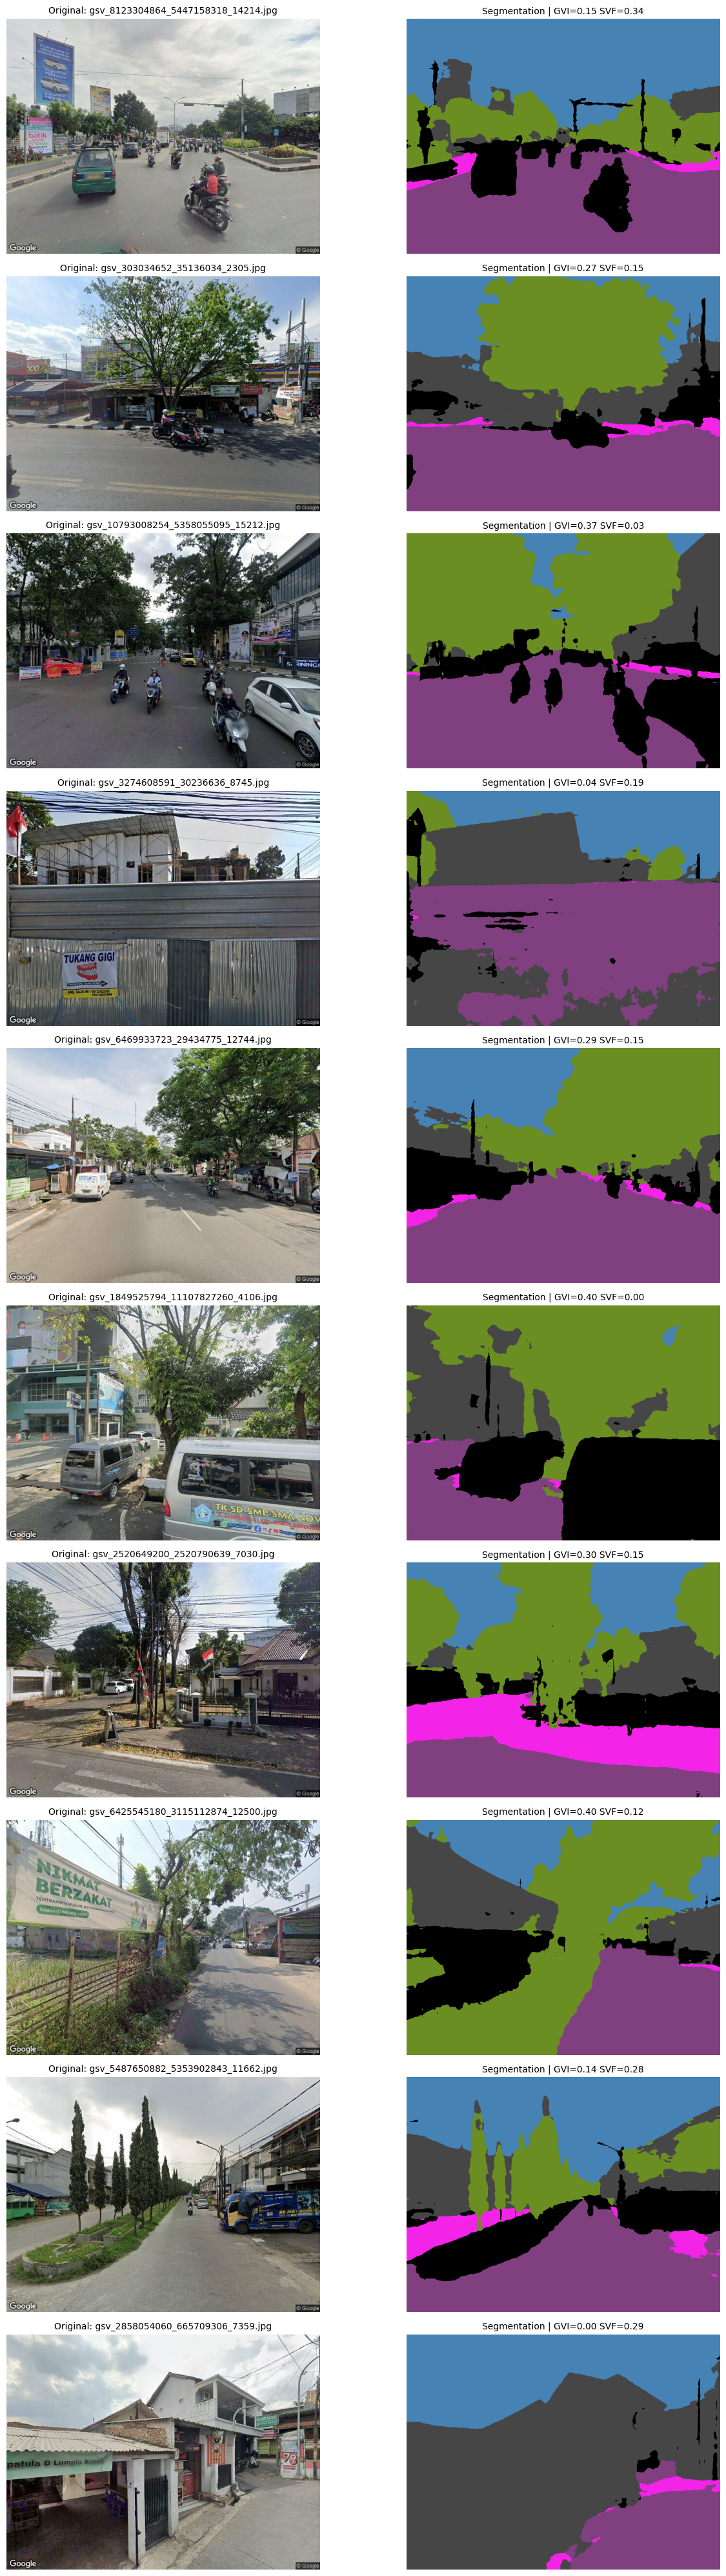

Preview disimpan ke data/segmentation_preview.png


In [8]:
# Tampilkan contoh segmentasi untuk 4 gambar
n_show = min(10, len(local_images))
fig, axes = plt.subplots(n_show, 2, figsize=(14, 4 * n_show))
if n_show == 1:
    axes = axes.reshape(1, -1)

for i in range(n_show):
    img_path = os.path.join(LOCAL_IMAGE_DIR, local_images[i])
    result = segment_image(img_path)
    if result:
        metrics, seg_map, original = result

        # Gambar asli
        axes[i, 0].imshow(original)
        axes[i, 0].set_title(f'Original: {local_images[i][:40]}', fontsize=10)
        axes[i, 0].axis('off')

        # Segmentation map dengan warna VISTA
        colored = np.zeros((*seg_map.shape, 3), dtype=np.uint8)
        for class_id, color in VISTA_COLORS.items():
            colored[seg_map == class_id] = color

        axes[i, 1].imshow(colored)
        gvi = metrics['green_view_index']
        svf = metrics['sky_view_factor']
        axes[i, 1].set_title(f'Segmentation | GVI={gvi:.2f} SVF={svf:.2f}', fontsize=10)
        axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'segmentation_preview.png'), dpi=150)
plt.show()
print('Preview disimpan ke data/segmentation_preview.png')

## 7. Simpan Hasil ke CSV

In [9]:
# Simpan skor per-gambar (detail)
output_csv_per_image = os.path.join(OUTPUT_DIR, 'physical_environment_score.csv')
df_results.to_csv(output_csv_per_image, index=False)
print(f'📊 Skor per-gambar disimpan ke:')
print(f'   {output_csv_per_image} ({len(df_results)} baris)')

# Simpan skor per-TAS-Nit (agregat)
if df_tasnit_scores is not None:
    output_csv_tasnit = os.path.join(OUTPUT_DIR, 'physical_environment_tasnit.csv')
    df_tasnit_scores.to_csv(output_csv_tasnit, index=False)
    print(f'📊 Skor per-TAS-Nit disimpan ke:')
    print(f'   {output_csv_tasnit} ({len(df_tasnit_scores)} baris)')

# Hapus file checkpoint parsial (sudah tidak diperlukan)
if os.path.exists(partial_csv):
    os.remove(partial_csv)
    print('\n🗑️ File checkpoint parsial dihapus.')

print(f'\n📋 Preview data per-gambar:')
df_results.head(10)

📊 Skor per-gambar disimpan ke:
   /content/drive/MyDrive/ai_pipeline/data/physical_environment_score.csv (17193 baris)
📊 Skor per-TAS-Nit disimpan ke:
   /content/drive/MyDrive/ai_pipeline/data/physical_environment_tasnit.csv (3494 baris)

🗑️ File checkpoint parsial dihapus.

📋 Preview data per-gambar:


,road_width_index,sidewalk_ratio,street_canyon_enclosure,green_view_index,sky_view_factor,filename,visual_perception_score,edge_id,point_index,tas_nit_id,street_name
0,0.3287,0.0156,0.0517,0.1502,0.3390,gsv_8123304864_5447158318_14214.jpg,0.3080,8123304864_5447158318,14214,8123304864_5447158318_STOP36,Jalan Soekarno-Hatta
1,0.3337,0.0168,0.1559,0.2683,0.1457,gsv_303034652_35136034_2305.jpg,0.2803,303034652_35136034,2305,303034652_35136034_STOP16,Jalan Abdul Haris Nasution
2,0.3104,0.0078,0.0905,0.3724,0.0348,gsv_10793008254_5358055095_15212.jpg,0.2894,10793008254_5358055095,15212,10793008254_5358055095_STOP306,Jalan L.L. RE. Martadinata
3,0.4095,0.0005,0.3251,0.0429,0.1857,gsv_3274608591_30236636_8745.jpg,0.2016,3274608591_30236636,8745,3274608591_30236636_STOP638,Jalan Cikutra
4,0.3705,0.0150,0.0704,0.2942,0.1535,gsv_6469933723_29434775_12744.jpg,0.3061,6469933723_29434775,12744,6469933723_29434775_STOP797,Jalan Lodaya
5,0.1365,0.0028,0.1650,0.4035,0.0027,gsv_1849525794_11107827260_4106.jpg,0.2612,1849525794_11107827260,4106,1849525794_11107827260_STOP713,Jalan Naripan
6,0.1804,0.1672,0.0849,0.2974,0.1550,gsv_2520649200_2520790639_7030.jpg,0.3167,2520649200_2520790639,7030,2520649200_2520790639_STOP695,Jalan Aceh
7,0.1883,0.0017,0.1577,0.3969,0.1214,gsv_6425545180_3115112874_12500.jpg,0.2949,6425545180_3115112874,12500,6425545180_3115112874_STOP498,Jalan Cigondewah Kaler
8,0.2807,0.0438,0.1190,0.1380,0.2778,gsv_5487650882_5353902843_11662.jpg,0.2798,5487650882_5353902843,11662,5487650882_5353902843_STOP198,NaN
9,0.1408,0.0162,0.5441,0.0000,0.2894,gsv_2858054060_665709306_7359.jpg,0.1581,2858054060_665709306,7359,2858054060_665709306_STOP425,"['Jalan Desa Cipadung', 'Jalan Cilengkrang II']"


## 8. Distribusi Skor

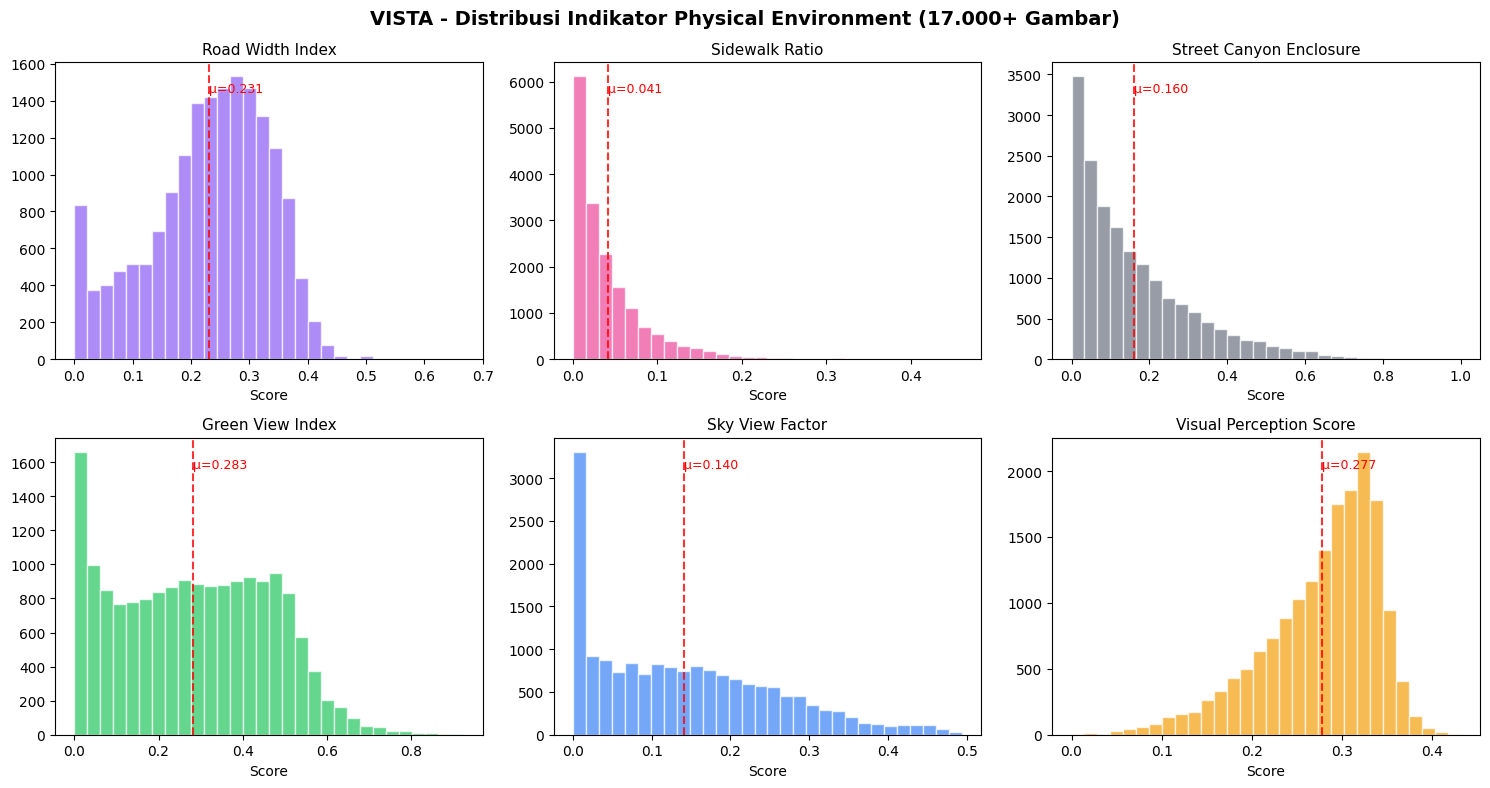

Grafik distribusi disimpan.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('VISTA - Distribusi Indikator Physical Environment (17.000+ Gambar)', fontsize=14, fontweight='bold')

indicators = list(VISTA_CLASSES.keys()) + ['visual_perception_score']
colors = ['#8B5CF6', '#EC4899', '#6B7280', '#22C55E', '#3B82F6', '#F59E0B']

for idx, (col, color) in enumerate(zip(indicators, colors)):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df_results[col], bins=30, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Score')
    mean_val = df_results[col].mean()
    median_val = df_results[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8)
    ax.text(mean_val, ax.get_ylim()[1]*0.9, f'μ={mean_val:.3f}', color='red', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'physical_env_distribution.png'), dpi=150)
plt.show()
print('Grafik distribusi disimpan.')

## 9. Statistik & Insight

Ringkasan temuan dari analisis Physical Environment seluruh Kota Bandung.

In [11]:
print('='*60)
print('📊 RINGKASAN ANALISIS PHYSICAL ENVIRONMENT - KOTA BANDUNG')
print('='*60)
print(f'\nTotal gambar diproses: {len(df_results)}')
if df_tasnit_scores is not None:
    print(f'Total TAS-Nits tercakup: {len(df_tasnit_scores)}')

print(f'\n--- Statistik Indikator ---')
for col in indicators:
    mean = df_results[col].mean()
    std = df_results[col].std()
    min_val = df_results[col].min()
    max_val = df_results[col].max()
    print(f'  {col:30s}: μ={mean:.4f} ± {std:.4f} (min={min_val:.4f}, max={max_val:.4f})')

print(f'\n--- Insight Utama ---')
gvi_mean = df_results['green_view_index'].mean()
svf_mean = df_results['sky_view_factor'].mean()
sw_mean = df_results['sidewalk_ratio'].mean()

if gvi_mean > 0.25:
    print(f'🌳 Green View Index rata-rata {gvi_mean:.1%} — Bandung memiliki kanopi pohon yang BAIK di koridor utama')
else:
    print(f'⚠️ Green View Index rata-rata {gvi_mean:.1%} — Penghijauan di koridor transportasi perlu ditingkatkan')

if sw_mean < 0.05:
    print(f'🚶 Sidewalk Ratio rata-rata {sw_mean:.1%} — Trotoar sangat MINIM, hambatan utama walkability menuju halte')
elif sw_mean < 0.15:
    print(f'🚶 Sidewalk Ratio rata-rata {sw_mean:.1%} — Trotoar cukup, namun masih bisa ditingkatkan')

print(f'🏙️ Sky View Factor rata-rata: {svf_mean:.1%}')

print(f'\n✅ Data siap untuk Tahap 5 (Urban Vitality Index Calculation)!')

📊 RINGKASAN ANALISIS PHYSICAL ENVIRONMENT - KOTA BANDUNG

Total gambar diproses: 17193
Total TAS-Nits tercakup: 3494

--- Statistik Indikator ---
  road_width_index              : μ=0.2305 ± 0.1032 (min=0.0000, max=0.6670)
  sidewalk_ratio                : μ=0.0411 ± 0.0462 (min=0.0000, max=0.4608)
  street_canyon_enclosure       : μ=0.1601 ± 0.1515 (min=0.0000, max=0.9997)
  green_view_index              : μ=0.2828 ± 0.1817 (min=0.0000, max=0.9249)
  sky_view_factor               : μ=0.1404 ± 0.1173 (min=0.0000, max=0.4941)
  visual_perception_score       : μ=0.2772 ± 0.0634 (min=0.0000, max=0.4312)

--- Insight Utama ---
🌳 Green View Index rata-rata 28.3% — Bandung memiliki kanopi pohon yang BAIK di koridor utama
🚶 Sidewalk Ratio rata-rata 4.1% — Trotoar sangat MINIM, hambatan utama walkability menuju halte
🏙️ Sky View Factor rata-rata: 14.0%

✅ Data siap untuk Tahap 5 (Urban Vitality Index Calculation)!


---
## ✅ Selesai!

File output yang dihasilkan:
- `data/physical_environment_score.csv` — Skor Physical Environment per gambar (17.000+ baris)
- `data/physical_environment_tasnit.csv` — Skor Physical Environment per TAS-Nit (5.876 baris) ← **FILE INI YANG DIPAKAI DI TAHAP 5**
- `data/segmentation_preview.png` — Contoh visual segmentasi
- `data/physical_env_distribution.png` — Distribusi skor

### Langkah Selanjutnya:
1. Download file `physical_environment_tasnit.csv` dari Google Drive
2. Taruh di folder `ai_pipeline/data/` di laptop Anda
3. File ini akan digabung dengan `accessibility_score.csv` untuk membentuk **Urban Vitality Index (UVI)** pada Tahap 5